In [1]:
import json
import time

import cloudscraper
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

/Users/nikhilreddy/Git Projects/algowatch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get initial data (title, episodes, rating, link)

In [ ]:
# Code for just page 1

url = "https://mydramalist.com/shows/top?page=1"
headers =     {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"}
scraper = cloudscraper.create_scraper()
html = scraper.get(url).text
soup = BeautifulSoup(html, "html.parser")

In [ ]:
base_url = "https://mydramalist.com/shows/top?page={}"
headers =     {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"}
scraper = cloudscraper.create_scraper()

shows = []

for page in tqdm(range(1, 101)):
    
    url = base_url.format(page)
    html = scraper.get(url).text
    soup = BeautifulSoup(html, "html.parser")

    for box in soup.select("div.box-body"):
        # title + link
        title_tag = box.select_one("h6.text-primary.title a")
        if not title_tag:
            continue
        title = title_tag.text.strip()
        link = "https://mydramalist.com" + title_tag["href"]

        # year and episodes
        meta = box.select_one("span.text-muted").text.strip()
        # Example: "Korean Drama - 2025, 16 episodes"
        parts = meta.split(" - ")
        year, episodes = None, None
        media_type = parts[0].strip() if parts else None
        if len(parts) > 1:
            year_info = parts[1]
            if "," in year_info:
                year, episodes = [p.strip() for p in year_info.split(",", 1)]
                # Remove " episodes" suffix
                episodes = episodes.replace(" episodes", "")
            else:
                year = year_info.strip()

        # rating
        rating_tag = box.select_one("span.p-l-xs.score")
        rating = rating_tag.text.strip() if rating_tag else None

        shows.append({
            "title": title,
            "media_type": media_type,
            "year": year,
            "episodes": episodes,
            "rating": rating,
            "link": link
        })

print(f"{len(shows)} shows found")
for s in shows[:5]:
    print(s)

In [ ]:
# with open("mydramalist_kdramas_v2.json", "w", encoding="utf-8") as f:
#     json.dump(shows, f, ensure_ascii=False, indent=2)

In [ ]:
with open("mydramalist_kdramas_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

Add description, genre, tags, and actor info

In [ ]:
scraper = cloudscraper.create_scraper()

for entry in tqdm(data):
    url = entry["link"]
    response = scraper.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    # --- Description ---
    desc_tag = soup.select_one(".show-synopsis p span")  # adjust if needed
    if desc_tag:
        full_text = desc_tag.get_text(separator=" ", strip=True)
        # Optional: remove any leftover \n explicitly
        full_text = full_text.replace("\n", " ")
        # Split at "(Source" and take only the first part
        entry["description"] = full_text.split("(Source")[0].strip()
    else:
        entry["description"] = None

    # --- Genres ---
    genre_tags = soup.select("li.show-genres a.text-primary")
    entry["genres"] = [g.get_text(strip=True) for g in genre_tags] if genre_tags else []

    # --- Tags ---
    tag_tags = soup.select("li.show-tags a.text-primary")
    entry["tags"] = [t.get_text(strip=True) for t in tag_tags] if tag_tags else []

    # --- Actors ---
    # Select all actor list items
    actor_tags = soup.select("ul.list.no-border.p-b.credits li b[itempropx='name']")
    # Get text for each actor
    entry["main_actors"] = [a.get_text(strip=True) for a in actor_tags] if actor_tags else []

# # Save back to JSON
# with open("mydramalist_kdramas.json", "w", encoding="utf-8") as f:
#     json.dump(data, f, ensure_ascii=False, indent=2)

In [ ]:
with open("mydramalist_kdramas_v2.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

## Analyze data

In [ ]:
with open("mydramalist_kdramas_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [2]:
df = pd.read_json("mydramalist_kdramas_v2.json")
df.head()

,title,media_type,year,episodes,rating,link,description,genres,tags,main_actors
0,When Life Gives You Tangerines,Korean Drama,2025,16,9.3,https://mydramalist.com/735043-life,It is a story that resembles a tribute to our ...,"[Romance, Life, Drama]","[Family Relationship, Nice Male Lead, Healthy ...","[IU, Park Bo Gum, Moon So Ri, Park Hae Joon, K..."
1,Twinkling Watermelon,Korean Drama,2023,16,9.2,https://mydramalist.com/739603-sparkling-water...,"In 2023, high school student Eun Gyeol, a CODA...","[Romance, Youth, Drama, Fantasy]","[Time Travel, Child From The Future, Deafness,...","[Ryeo Un, Choi Hyun Wook, Seol In Ah, Shin Eun..."
2,Move to Heaven,Korean Drama,2021,10,9.1,https://mydramalist.com/49231-move-to-heaven,Han Geu Roo is an autistic 20-year-old. He wor...,"[Life, Drama]","[Uncle-Nephew Relationship, Autism, Death, Tea...","[Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, J..."
3,Weak Hero Class 1,Korean Drama,2022,8,9.1,https://mydramalist.com/702267-weak-hero,Yeon Shi Eun is a model student who ranks at t...,"[Action, Youth, Drama]","[Student Male Lead, Teenager Male Lead, Violen...","[Park Ji Hoon, Choi Hyun Wook, Hong Kyung, Kim..."
4,Alchemy of Souls,Korean Drama,2022,20,9.1,https://mydramalist.com/52939-can-this-person-...,"In the fictional country of Daeho, young mages...","[Action, Historical, Romance, Fantasy]","[Transmigration, Master-Disciple Relationship,...","[Lee Jae Wook, Jung So Min, Hwang Min Hyun, Sh..."


In [ ]:
print(len(df["media_type"].unique()), "unique media types")
print(len(df["genres"].explode().unique()), "unique genres")
print(len(df["tags"].explode().unique()), "unique tags")
print(len(df["main_actors"].explode().unique()), "unique actors")

In [ ]:
df[df["title"].str.lower().str.contains("our beloved")]

In [ ]:
df['genres'][0]

## Test out embeddings

In [ ]:
df = pd.read_json("mydramalist_kdramas_v2.json")

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")


In [ ]:
# Create combined text for embeddings
def create_embedding_text(row):
    title = row.get('title', '')
    media_type = row.get('media_type', '')
    genres = ', '.join(row.get('genres', [])) if isinstance(row.get('genres'), list) else ''
    tags = ', '.join(row.get('tags', [])) if isinstance(row.get('tags'), list) else ''
    description = row.get('description', '') or ''
    
    text = f"Title: {title}; Media Type: {media_type}; Genres: {genres}; Tags: {tags}; Description: {description}"
    return text

df['embedding_text'] = df.apply(create_embedding_text, axis=1)
df['embedding_text'].head()

In [ ]:
drama_texts = df['embedding_text'].to_list()

In [ ]:
embeddings = model.encode(drama_texts, normalize_embeddings=True)

In [ ]:
embeddings.shape

In [ ]:
# np.save("drama_embeddings.npy", embeddings)

In [ ]:
# compare twinkling watermelon to see most similar show
# feature space is 384
scores = cosine_similarity([embeddings[1]], embeddings)[0]

In [ ]:
top_idx = scores.argsort()[::-1]

In [ ]:
top_idx

In [ ]:
df.iloc[top_idx].head(6)

## Umap embedding space visualization

In [3]:
import numpy as np

In [4]:
embeddings = np.load("drama_embeddings.npy")

In [ ]:
import umap

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, transform_mode="embedding")
embedding_2d = reducer.fit_transform(embeddings)

In [ ]:
# Save umap and projected vectors
import joblib

# np.save("drama_embeddings_2d.npy", embedding_2d)
# joblib.dump(reducer, "umap_model.pkl")

In [ ]:
# cluster labels visualization, something to try out later, also try taste vectors for genres
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
clusters = clusterer.fit_predict(drama_embeddings)

#### Visualize the umap

In [9]:
embedding_2d = np.load("drama_embeddings_2d.npy")

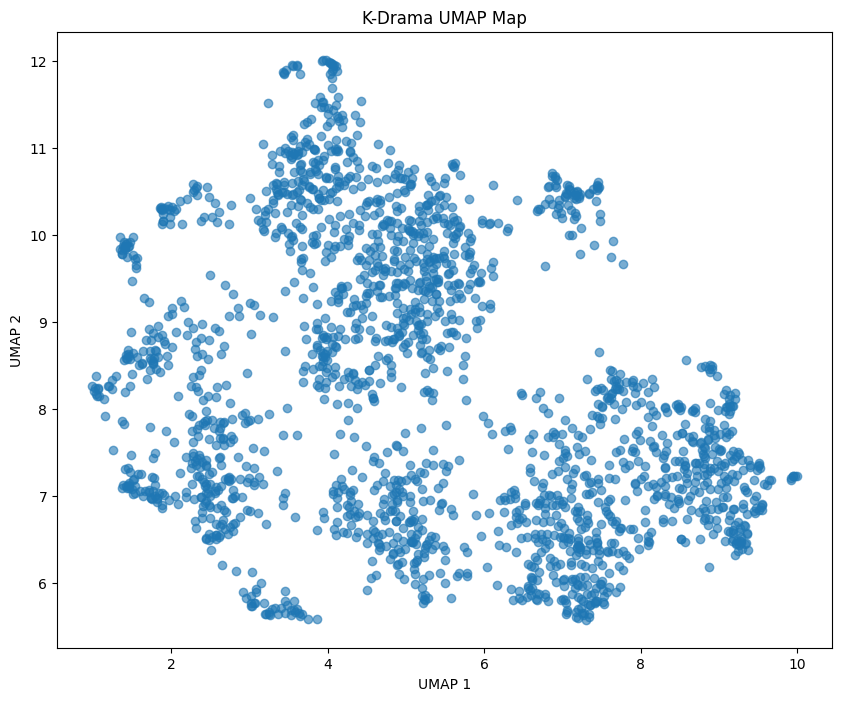

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    alpha=0.6
)

plt.title("K-Drama UMAP Map")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

In [11]:
df["media_type"].astype("category")

0         Korean Drama
1         Korean Drama
2         Korean Drama
3         Korean Drama
4         Korean Drama
             ...      
1995      Korean Drama
1996    Japanese Drama
1997      Korean Drama
1998    Japanese Drama
1999      Korean Drama
Name: media_type, Length: 2000, dtype: category
Categories (14, object): ['Chinese Drama', 'Chinese Special', 'Filipino Drama', 'Filipino Special', ..., 'Taiwanese Drama', 'Taiwanese Special', 'Thai Drama', 'Thai Special']

In [12]:
df["media_type"].astype("category").cat.categories

Index(['Chinese Drama', 'Chinese Special', 'Filipino Drama',
       'Filipino Special', 'Hong Kong Drama', 'Japanese Drama',
       'Japanese Special', 'Korean Drama', 'Korean Special',
       'Singaporean Drama', 'Taiwanese Drama', 'Taiwanese Special',
       'Thai Drama', 'Thai Special'],
      dtype='object')

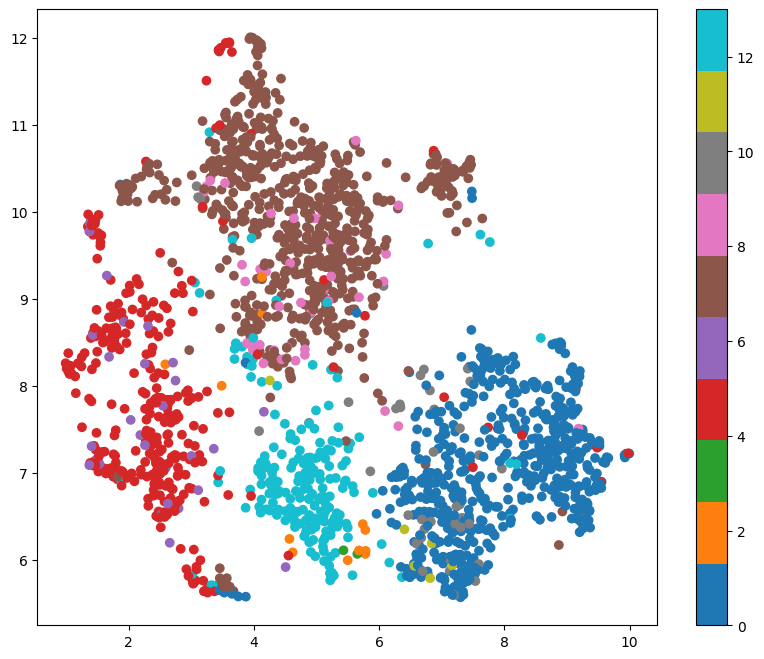

In [13]:
colors = df["media_type"].astype("category").cat.codes

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=colors,
    cmap="tab10",
    alpha=1
)

plt.colorbar()
plt.show()

In [14]:
import plotly.express as px

fig = px.scatter(
    x=embedding_2d[:,0],
    y=embedding_2d[:,1],
    hover_name=df["title"],
    color=df["media_type"],
)

fig.show()